In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import pickle
import scipy
from dantro.plot.utils import ColorManager
import matplotlib.gridspec as gridspec
import matplotlib.colorbar as colorbar
import torch
import tqdm
from matplotlib.colorbar import Colorbar
from matplotlib.lines import Line2D

from ruamel.yaml import YAML

from nn import NeuralNet, Sinkhorn, marginals_and_transport_plan

yaml = YAML(typ="safe")

from _style import colors, rcParams

In [2]:
# Thesis
page_width = 6.8246 # 6.25598 #
# fs=8
# rcParams.update(**{"font.family": "Arial", "font.size": fs, "axes.titlesize": fs, "axes.labelsize": fs, "xtick.labelsize": fs, "ytick.labelsize": fs, "legend.fontsize": fs})
img_dir = "../Revision/" #"/Users/thomasgaskin/Projects/Thesis/OT/SI"

In [3]:
# ColorManager for the transport plan
cm_T = ColorManager(cmap={'continuous': True, 'from_values': {0: colors['c_darkblue'], 0.5: colors['c_lightblue'], 1: colors['c_yellow']}})

# ColorManager for the cost matrix
cm_C = ColorManager(cmap={'continuous': True, 'from_values': {0: colors['c_red'], 0.5: colors['c_yellow'], 1: colors['c_darkgreen']}})

In [144]:
# Helper function to train on synthetic data
def infer_on_synthetic_data(*, NN, mu, nu, T, n_epochs, mask = None, C_mask, epsilon: str | float, eta=1e-5, show_pbar: bool = True, **sinkhorn_kwargs):

    if mask is None:
        mask = torch.ones_like(T).bool()

    infer_epsilon = epsilon == 'infer'
    if infer_epsilon:
        epsilon_ts = []
    # Train
    for _ in (pbar:=tqdm.trange(n_epochs)) if show_pbar else range(n_epochs):

        # Make a prediction
        _pred = NN(T.reshape(NN.input_dim, ))
        if infer_epsilon:
            epsilon = _pred[-1]*0.98+0.02
            epsilon_ts.append(epsilon.clone().detach())
            _C_pred = _pred[:-1].reshape(T.shape)
        else:
            _C_pred = _pred.reshape(T.shape)

        # Get the marginals from the predicted cost matrix
        _m, _n = Sinkhorn(
            mu,
            nu,
            _C_pred,
            epsilon=epsilon,
            **sinkhorn_kwargs,
        )

        _, _, _T_pred = marginals_and_transport_plan(_m, _n, _C_pred, epsilon=epsilon)

        # Training loss = L2 loss
        loss = torch.nn.functional.mse_loss(
            torch.masked_select(_T_pred, mask).log(),
            torch.masked_select(T, mask).log()
        )

        # Force C to attain the maximum value on masked edges
        # It is important to balance the regulariser with the prediction loss
        loss = loss + eta*torch.nn.functional.mse_loss(
            torch.masked_select(_C_pred, C_mask),
            torch.ones_like(torch.masked_select(_C_pred.clone().detach(), C_mask))
        )

        # Perform a gradient descent step every B iterations
        loss.backward()
        NN.optimizer.step()
        NN.optimizer.zero_grad()

        pbar.set_description(f"Loss: {loss:>.4g}")
    if infer_epsilon:
        return torch.stack(epsilon_ts)

# Helper function to evaluate trained networks
def make_preds_from_NN(*, NN, mu, nu, T, epsilon: str | float, **sinkhorn_kwargs):

    infer_epsilon = epsilon == 'infer'
    _pred = NN(T.reshape(NN.input_dim, )).detach()
    if infer_epsilon:
        epsilon = 0.98*_pred[-1]+0.02
        C_pred = _pred[:-1].reshape(T.shape)
    else:
        C_pred = _pred.reshape(T.shape)
    _m, _n = Sinkhorn(
        mu,
        nu,
        C_pred,
        epsilon=epsilon,
        **sinkhorn_kwargs,
    )
    _, _, T_pred = marginals_and_transport_plan(_m, _n, C_pred, epsilon=epsilon)
    return C_pred, T_pred

# Validation on synthetic data

## Varying $\varepsilon$
We vary the entropy regulariser and assess the change in performance.

In [114]:
# Generate a synthetic cost matrix with a solution
M, N = 23, 23
m, n = 0.5+torch.rand((M, 1)), 0.5 + torch.rand((1, N))
C = torch.stack([torch.stack([torch.tensor(abs(i-j)/(N+M)) for i in range(N)]) for j in range(M)])
C.fill_diagonal_(1.0)

# Sinkhorn algorithm settings
sinkhorn_kwargs = dict(max_iter=100, tolerance=1e-5, normalise=False)

In [6]:
# Set up a dictionary of neural networks for different values of epsilon
neural_nets = dict(
    (eps,
     dict(NN=NeuralNet(
            input_size=M*N,
            output_size=M*N,
            num_layers=3,
            nodes_per_layer=dict(default=20),
            activation_funcs=dict(default='tanh', layer_specific={-1: 'sigmoid'}),
            biases=dict(default=None),
            optimizer='Adam',
            learning_rate=0.002
    ),
     T=m*torch.exp(-C/eps)*n,
     mu=(m*torch.exp(-C/eps)*n).sum(dim=1, keepdim=True),
     nu=(m*torch.exp(-C/eps)*n).sum(dim=0, keepdim=True))) for eps in [0.02, 0.05, 0.1, 1])

In [7]:
# Now infer the cost matrix for different epsilons and plot the accuracy
for eps, v in neural_nets.items():
    infer_on_synthetic_data(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], n_epochs=1000, C_mask=C==1, eta=1e-5, epsilon=eps, **sinkhorn_kwargs)

    # Make a prediction
    C_pred, T_pred = make_preds_from_NN(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], epsilon=eps, **sinkhorn_kwargs)
    neural_nets[eps]['C_pred'] = C_pred
    neural_nets[eps]['T_pred'] = T_pred

Loss: 1.764e-06: 100%|██████████| 1000/1000 [00:01<00:00, 651.95it/s]


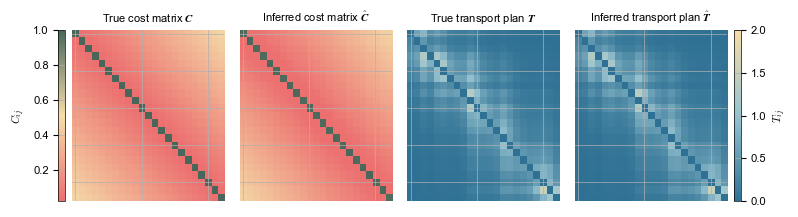

In [23]:
fig = plt.figure(figsize=(page_width, page_width/4))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.1, hspace=0.1)
fig.subplots_adjust(left=0.02, right=0.98)
axs=[]
for col in [0, 1, 2, 3]:
    axs.append(fig.add_subplot(gs[0, col]))
axs = np.array(axs).reshape(2, 2)
for ax in axs.flatten():
    for spine in ['bottom', 'left', 'top', 'right']:
        ax.spines[spine].set_visible(False)
        # Hide all ticks and tick labels
        ax.tick_params(
            left=False, right=False,
            bottom=False, top=False,
            labelleft=False, labelbottom=False
        )


# Cost matrices
im = axs[0, 0].imshow(C, cmap=cm_C.cmap, vmin=C.min(), vmax=C.max(), aspect='auto')
axs[0, 1].imshow(neural_nets[0.1]['C_pred'], cmap=cm_C.cmap, vmin=C.min(), vmax=C.max(), aspect='auto')
ax = fig.add_axes([0, 0, 0.01, 1])
cbar = colorbar.Colorbar(ax, im, ticklocation='left', label=r"$C_{ij}$")
cbar.outline.set_linewidth(0.5)

im = axs[1, 0].imshow(neural_nets[0.1]['T_pred'], cmap=cm_T.cmap, vmin=0, vmax=2, aspect='auto')
axs[1, 1].imshow(neural_nets[0.1]['T'], cmap=cm_T.cmap, vmin=0, vmax=2, aspect='auto')
ax = fig.add_axes([0.99, 0, 0.01, 1])
cbar = colorbar.Colorbar(ax, im, ticklocation='right', label=r"$T_{ij}$")
cbar.outline.set_linewidth(0.5)

axs[0, 0].set_title(r"True cost matrix $\boldsymbol{C}$")
axs[0, 1].set_title(r"Inferred cost matrix $\hat{\boldsymbol{C}}$")
axs[1, 0].set_title(r"True transport plan $\boldsymbol{T}$")
axs[1, 1].set_title(r"Inferred transport plan $\hat{\boldsymbol{T}}$")

fig.savefig(f"{img_dir}/uniqueness.pdf", pad_inches=0)

[None]

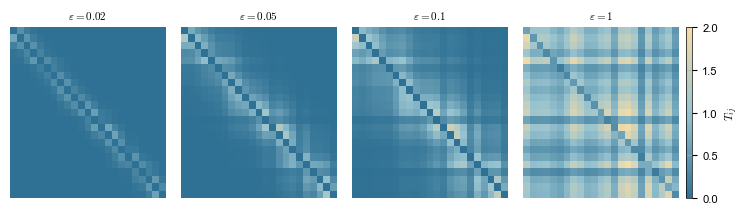

In [128]:
# Visualise the effect changing epsilon has
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(page_width, page_width/4), sharey=True, gridspec_kw=dict(wspace=0.1, hspace=0.2))
for ax in axs.flatten():
    ax.axis('off')
fig.subplots_adjust(right=0.98)

# Plot the transport plans for different values of epsilon
for idx, (eps, v) in enumerate(neural_nets.items()):
    im = axs[idx].imshow(
        v['T'], vmin=0, vmax=2, cmap=cm_T.cmap, aspect='auto'
    )
    axs[idx].set_title(rf"$\varepsilon={eps}$")

ax = fig.add_axes([0.99, 0., 0.01, 1])
cbar = colorbar.Colorbar(ax, im, ticklocation='right', label=r"$T_{ij}$")
cbar.outline.set(linewidth=0.5)

#fig.savefig(f"{img_dir}/epsilon_1.pdf", pad_inches=0.01)

In [25]:
# Set up a dictionary of neural networks for different values of epsilon
neural_nets_eps_sweep = dict(
    (eps,
     [dict(NN=NeuralNet(
            input_size=M*N,
            output_size=M*N,
            num_layers=3,
            nodes_per_layer=dict(default=20),
            activation_funcs=dict(default='tanh', layer_specific={-1: 'sigmoid'}),
            biases=dict(default=None),
            optimizer='Adam',
            learning_rate=0.002
    ),
     T=m*torch.exp(-C/eps)*n,
     mu=(m*torch.exp(-C/eps)*n).sum(dim=1, keepdim=True),
     nu=(m*torch.exp(-C/eps)*n).sum(dim=0, keepdim=True)) for _ in range(5)]) for eps in [0.02, 0.05, 0.1, 0.5, 1])

In [26]:
# Now infer the cost matrix for different epsilons and plot the accuracy
for eps, item in neural_nets_eps_sweep.items():
    for idx, v in enumerate(item):
        infer_on_synthetic_data(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], n_epochs=5000, C_mask=C==1, eta=1e-9, epsilon=eps, **sinkhorn_kwargs)

        # Make a prediction
        C_pred, T_pred = make_preds_from_NN(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], epsilon=eps, **sinkhorn_kwargs)
        neural_nets_eps_sweep[eps][idx]['C_pred'] = C_pred
        neural_nets_eps_sweep[eps][idx]['T_pred'] = T_pred

Loss: 7.253e-10: 100%|██████████| 5000/5000 [00:11<00:00, 426.15it/s]


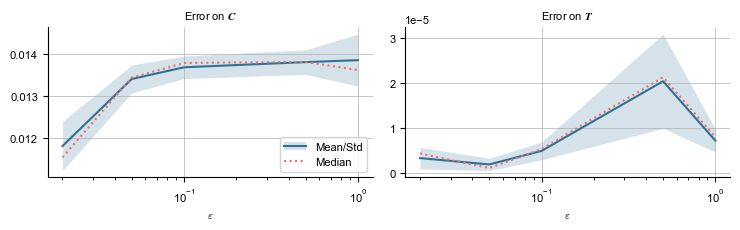

In [32]:
# Show the inference performance as epsilon changes
fig, axs = plt.subplots(figsize=(page_width, 1.5), ncols=2, gridspec_kw={'wspace': 0.1})

epsilon_values = list(neural_nets_eps_sweep.keys())
C_err = torch.stack([torch.stack([torch.abs(C-v[idx]['C_pred']).mean() for idx in range(len(v))]) for v in neural_nets_eps_sweep.values()])
T_err = torch.stack([torch.stack([torch.abs(v[idx]['T_pred']-v[idx]['T']).mean() for idx in range(len(v))]) for v in neural_nets_eps_sweep.values()])

_err = axs[0].fill_between(epsilon_values, C_err.mean(dim=1)-C_err.std(dim=1), C_err.mean(dim=1)+C_err.std(dim=1), alpha=0.2, color=colors['c_darkblue'], lw=0)
_mean = axs[0].plot(epsilon_values, C_err.mean(dim=1))
_med = axs[0].plot(epsilon_values, torch.median(C_err, dim=1)[0], ls='dotted')
axs[0].legend(handles=[(_err, _mean[0]), _med[0]], labels=['Mean/Std', 'Median'])#, framealpha=0, handlelength=1)

axs[1].fill_between(epsilon_values, T_err.mean(dim=1)-T_err.std(dim=1), T_err.mean(dim=1)+T_err.std(dim=1), alpha=0.2, color=colors['c_darkblue'], lw=0)
axs[1].plot(epsilon_values, T_err.mean(dim=1))
axs[1].plot(epsilon_values, torch.median(T_err, dim=1)[0], ls='dotted')

axs[0].set_title(r"Error on $\boldsymbol{C}$")
axs[1].set_title(r"Error on $\boldsymbol{T}$")

for ax in axs:
    ax.set_xlabel(r'$\varepsilon$')
    ax.set(xscale='log')

In [33]:
fig.savefig(f"{img_dir}/epsilon_2.pdf", pad_inches=0)

## Mask individual values of $T$
Now we mask individual values of the observed transport plan and check the performance on the edges.

In [29]:
# Set up a dictionary of neural networks for different values of epsilon
neural_nets_mask_sweep = dict(
    (p,
     [dict(NN=NeuralNet(
            input_size=M*N,
            output_size=M*N,
            num_layers=3,
            nodes_per_layer=dict(default=20),
            activation_funcs=dict(default='tanh', layer_specific={-1: 'sigmoid'}),
            biases=dict(default=None),
            optimizer='Adam',
            learning_rate=0.002
    ),
     T=m*torch.exp(-C/0.1)*n,
     mu=(m*torch.exp(-C/0.1)*n).sum(dim=1, keepdim=True),
     nu=(m*torch.exp(-C/0.1)*n).sum(dim=0, keepdim=True),
     mask=torch.bernoulli(p * torch.ones_like(C)).bool()) for _ in range(5)]) for p in np.linspace(0.1, 1, 10).round(2))
for p, item in neural_nets_mask_sweep.items():
    for idx, v in enumerate(item):
        neural_nets_mask_sweep[p][idx]['mask'].fill_diagonal_(True)

In [30]:
# Now infer the cost matrix for different epsilons and plot the accuracy
for p, item in neural_nets_mask_sweep.items():
    for idx, v in enumerate(item):

        infer_on_synthetic_data(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], n_epochs=5000, C_mask=C==1, mask=v['mask'], epsilon=0.1, eta=1e-6, **sinkhorn_kwargs)

        # Make a prediction
        C_pred, T_pred = make_preds_from_NN(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], epsilon=0.1, **sinkhorn_kwargs)
        neural_nets_mask_sweep[p][idx]['C_pred'] = C_pred
        neural_nets_mask_sweep[p][idx]['T_pred'] = T_pred

Loss: 3.955e-08: 100%|██████████| 5000/5000 [00:20<00:00, 242.17it/s]


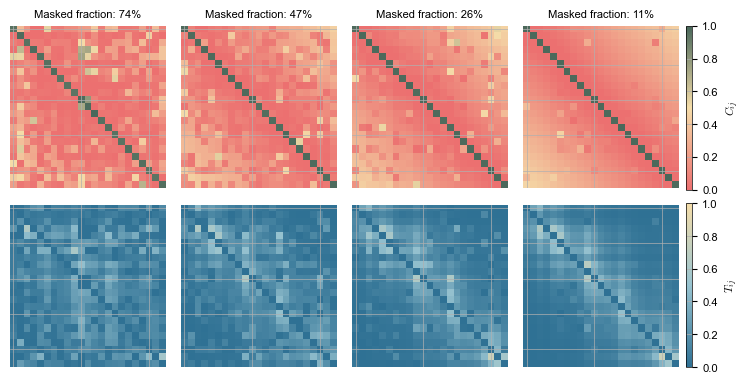

In [35]:
fig = plt.figure(figsize=(page_width, page_width/2))
gs = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 1], wspace=0.1, hspace=0.1)
axs=[]
for row in range(2):
    for col in range(4):
        axs.append(fig.add_subplot(gs[row, col]))
axs = np.array(axs).reshape(2, 4)
for idx, p in enumerate([0.2, 0.5, 0.7, 0.9]):
    item = neural_nets_mask_sweep[p]
    axs[0, idx].imshow(torch.where(item[0]['mask'], item[0]['C_pred'], item[0]['C_pred']), cmap=cm_C.cmap, vmin=C.min(), vmax=C.max(), aspect='auto')
    axs[1, idx].imshow(torch.where(item[0]['mask'], item[0]['T_pred'], item[0]['T_pred']), cmap=cm_T.cmap, vmin=0, vmax=2, aspect='auto')
    axs[0, idx].set_title(f"Masked fraction: {100*(1-item[0]['mask'].float().mean()):>.0f}%")
for ax in axs.flatten():
    for spine in ['bottom', 'left', 'top', 'right']:
        ax.spines[spine].set_visible(False)
        # Hide all ticks and tick labels
        ax.tick_params(
            left=False, right=False,
            bottom=False, top=False,
            labelleft=False, labelbottom=False
        )
fig.subplots_adjust(right=0.98)
ax = fig.add_axes([0.99, 0.52, 0.01, 0.48])
cbar = colorbar.Colorbar(ax, cmap=cm_C.cmap, ticklocation='right', label=r"$C_{ij}$")
cbar.outline.set(linewidth=0.5)
ax = fig.add_axes([0.99, 0.0, 0.01, 0.48])
cbar = colorbar.Colorbar(ax, cmap=cm_T.cmap, ticklocation='right', label=r"$T_{ij}$")
cbar.outline.set(linewidth=0.5)

fig.savefig(f"{img_dir}/masking_1.pdf", pad_inches=0)

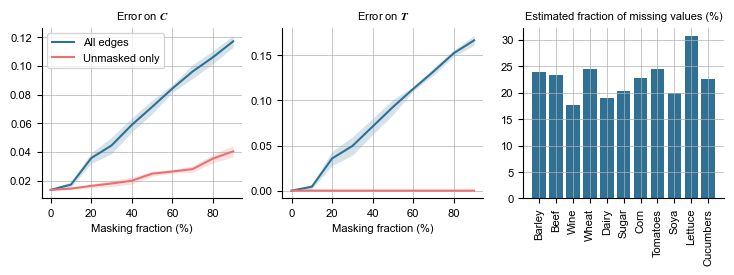

In [37]:
fig, axs = plt.subplots(figsize=(page_width, page_width/4), ncols=3, gridspec_kw={'wspace': 0.2})
p_vals = 100*(1-np.array(list(neural_nets_mask_sweep.keys())))

C_err = torch.stack([torch.stack([torch.abs(C-v[idx]['C_pred']).mean() for idx in range(len(v))]) for v in neural_nets_mask_sweep.values()])
T_err = torch.stack([torch.stack([torch.abs(v[idx]['T_pred']-v[idx]['T']).mean() for idx in range(len(v))]) for v in neural_nets_mask_sweep.values()])

axs[0].fill_between(p_vals, C_err.mean(dim=1)-C_err.std(dim=1), C_err.mean(dim=1)+C_err.std(dim=1), alpha=0.2, color=colors['c_darkblue'], lw=0)
axs[0].plot(p_vals, C_err.mean(dim=1),  label='All edges')
C_err = torch.stack([torch.stack([torch.nanmean(torch.where(v[idx]['mask'], torch.abs(C-v[idx]['C_pred']), torch.nan)) for idx in range(len(v))]) for v in neural_nets_mask_sweep.values()])
axs[0].fill_between(p_vals, C_err.mean(dim=1)-C_err.std(dim=1), C_err.mean(dim=1)+C_err.std(dim=1), alpha=0.2, color=colors['c_red'], lw=0)
axs[0].plot(p_vals, C_err.mean(dim=1), label='Unmasked only')

axs[0].legend()

axs[1].fill_between(p_vals, T_err.mean(dim=1)-T_err.std(dim=1), T_err.mean(dim=1)+T_err.std(dim=1), alpha=0.2, color=colors['c_darkblue'], lw=0)
axs[1].plot(p_vals, T_err.mean(dim=1))

# Plot the error on the unmasked values only
T_err = torch.stack([torch.stack([torch.nanmean(torch.where(v[idx]['mask'], torch.abs(v[idx]['T_pred']-v[idx]['T']), torch.nan)) for idx in range(len(v))]) for v in neural_nets_mask_sweep.values()])

axs[1].fill_between(p_vals, T_err.mean(dim=1)-T_err.std(dim=1), T_err.mean(dim=1)+T_err.std(dim=1), alpha=0.2, color=colors['c_red'], lw=0)
axs[1].plot(p_vals, T_err.mean(dim=1))

axs[0].set_title(r"Error on $\boldsymbol{C}$")
axs[1].set_title(r"Error on $\boldsymbol{T}$")
for ax in axs[:-1]:
    ax.set_xlabel("Masking fraction (%)")

# Plot the estimated number of missing entries in the FAO data
missing_fracs = {}
for _source in ["Barley", "Beef", "Wine", "Wheat", ("Dairy", "Dairy_all"), ("Sugar", "Sugar_products"), "Corn", "Tomatoes", ("Soya", "Soya_beans"), ("Lettuce", "Vegetables"), ("Cucumbers", "Cucumbers_and_gherkins")]:
    if isinstance(_source, tuple):
        _name, _source = _source
    else:
        _name = _source
    FAO_data=xr.open_dataarray(f"data/FAO_Data/{_source}_pooled_0.99_2000-2022.nc")

    missing_fracs[_name] = 100*((((FAO_data.sel({"Reporter": "Exporter"}) == 0) & (FAO_data.sel({"Reporter": "Importer"}) != 0)).sum() + ((FAO_data.sel({"Reporter": "Exporter"}) != 0) & (FAO_data.sel({"Reporter": "Importer"}) == 0)).sum()) / (FAO_data > 0).sum()).data.item()

    # Mask that constrains the cost matrix to be 1
    C_mask = torch.from_numpy((FAO_data == 0).all(dim=['Element', 'Reporter']).expand_dims({"Reporter": ['Exporter', 'Importer']}).stack({'idx': ['Year', 'Reporter']}).drop_vars(['Year', 'Reporter']).transpose('idx', ...).data).bool()

axs[2].bar(list(missing_fracs.keys()), list(missing_fracs.values()))
axs[2].set_title("Estimated fraction of missing values (%)")
axs[2].tick_params(axis='x', rotation=90)

fig.savefig(f"{img_dir}/masking_2.pdf", pad_inches=0)

## Learning epsilon

In [125]:
neural_nets_eps = dict(
    (eps,
     dict(NN=NeuralNet(
            input_size=M*N,
            output_size=M*N+1,
            num_layers=3,
            nodes_per_layer=dict(default=20),
            activation_funcs=dict(default='tanh', layer_specific={-1: 'sigmoid'}),
            biases=dict(default=None),
            optimizer='Adam',
            learning_rate=0.002
    ),
     T=m*torch.exp(-C/eps)*n,
     mu=(m*torch.exp(-C/eps)*n).sum(dim=1, keepdim=True),
     nu=(m*torch.exp(-C/eps)*n).sum(dim=0, keepdim=True))) for eps in [0.02, 0.05, 0.1, 1])

In [145]:
# Now infer the cost matrix for different epsilons and plot the accuracy
for eps, v in neural_nets_eps.items():
    infer_on_synthetic_data(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], n_epochs=8000,
                            C_mask=C==1, eta=1e-5, epsilon='infer',
                            **sinkhorn_kwargs)

    # Make a prediction
    C_pred, T_pred = make_preds_from_NN(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], epsilon='infer', **sinkhorn_kwargs)
    neural_nets_eps[eps]['C_pred'] = C_pred
    neural_nets_eps[eps]['T_pred'] = T_pred
    neural_nets_eps[eps]['epsilon_pred'] = 0.98*v['NN'](v['T'].reshape(v['NN'].input_dim, ))[-1]+0.02

Loss: 4.068e-07: 100%|██████████| 8000/8000 [00:11<00:00, 715.21it/s]


[Text(0, 0.5, 'Inferred cost matrix')]

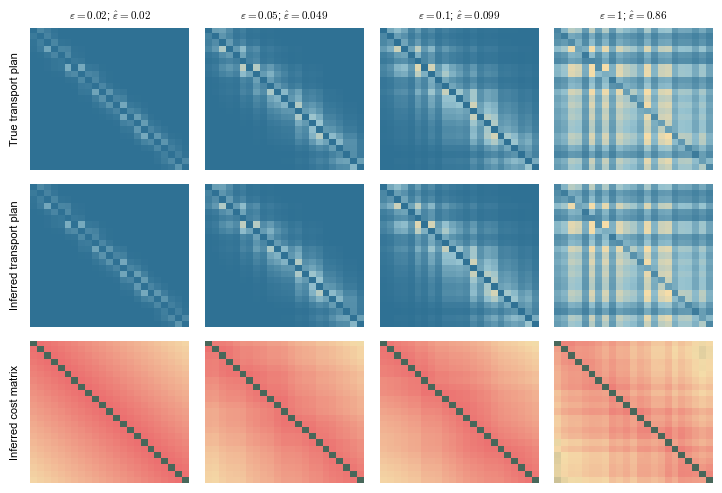

In [146]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(page_width, 2*page_width/3), gridspec_kw=dict(wspace=0.1, hspace=0.1))
for ax in axs.flatten():
    #ax.axis('off')
    ax.grid()
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(labelleft=False, width=0, labelbottom=False)
for idx, (eps, item) in enumerate(neural_nets_eps.items()):
    axs[0, idx].imshow(item['T'], cmap=cm_T.cmap, vmin=0, vmax=2, aspect='auto')
    axs[1, idx].imshow(item['T_pred'], cmap=cm_T.cmap, vmin=0, vmax=2, aspect='auto')
    axs[2, idx].imshow(item['C_pred'], cmap=cm_C.cmap, vmin=0, vmax=1, aspect='auto')
    axs[0, idx].set_title(fr"$\varepsilon={eps}$;" + r" $\hat{\varepsilon}=$"+fr"${item['epsilon_pred']:>.2g}$")
axs[0, 0].set(ylabel='True transport plan')
axs[1, 0].set(ylabel='Inferred transport plan')
axs[2, 0].set(ylabel='Inferred cost matrix')

In [122]:
# Set up a dictionary of neural networks for different values of epsilon
neural_nets_eps_sweep_2 = dict(
    (eps,
     [dict(NN=NeuralNet(
            input_size=M*N,
            output_size=M*N+1,
            num_layers=3,
            nodes_per_layer=dict(default=20),
            activation_funcs=dict(default='tanh', layer_specific={-1: 'sigmoid'}),
            biases=dict(default=None),
            optimizer='Adam',
            learning_rate=0.002
    ),
     T=m*torch.exp(-C/eps)*n,
     mu=(m*torch.exp(-C/eps)*n).sum(dim=1, keepdim=True),
     nu=(m*torch.exp(-C/eps)*n).sum(dim=0, keepdim=True)) for _ in range(5)]) for eps in np.linspace(0.02, 1, 17))

In [123]:
# Now infer the cost matrix for different epsilons and plot the accuracy
for eps, item in neural_nets_eps_sweep_2.items():
    for idx, v in enumerate(item):
        infer_on_synthetic_data(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], n_epochs=1000, C_mask=C==1, eta=1e-3, epsilon='infer', **sinkhorn_kwargs)

        # Make a prediction
        C_pred, T_pred = make_preds_from_NN(NN=v['NN'], T=v['T'], mu=v['mu'], nu=v['nu'], epsilon='infer', **sinkhorn_kwargs)
        neural_nets_eps_sweep_2[eps][idx]['C_pred'] = C_pred
        neural_nets_eps_sweep_2[eps][idx]['T_pred'] = T_pred
        neural_nets_eps_sweep_2[eps][idx]['epsilon_pred'] = 0.98*v['NN'](v['T'].reshape(v['NN'].input_dim, )).detach()[-1]+0.02

Loss: 9.546e-06: 100%|██████████| 1000/1000 [00:01<00:00, 611.38it/s]


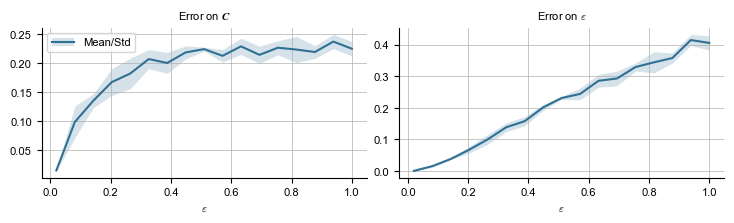

In [132]:
# Show the inference performance as epsilon changes
fig, axs = plt.subplots(figsize=(page_width, 1.5), ncols=2, gridspec_kw={'wspace': 0.1})

epsilon_values = list(neural_nets_eps_sweep_2.keys())
C_err = torch.stack([torch.stack([torch.abs(C-v[idx]['C_pred']).mean() for idx in range(len(v))]) for v in neural_nets_eps_sweep_2.values()])
eps_err = torch.stack([torch.stack([torch.abs(epsilon_values[i]-v[idx]['epsilon_pred']).mean() for idx in range(len(v))]) for i, v in enumerate(neural_nets_eps_sweep_2.values())])

_err = axs[0].fill_between(epsilon_values, C_err.mean(dim=1)-C_err.std(dim=1), C_err.mean(dim=1)+C_err.std(dim=1), alpha=0.2, color=colors['c_darkblue'], lw=0)
_mean = axs[0].plot(epsilon_values, C_err.mean(dim=1))
axs[0].legend(handles=[(_err, _mean[0])], labels=['Mean/Std'])#, framealpha=0, handlelength=1)

axs[1].fill_between(epsilon_values, eps_err.mean(dim=1)-eps_err.std(dim=1), eps_err.mean(dim=1)+eps_err.std(dim=1), alpha=0.2, color=colors['c_darkblue'], lw=0)
axs[1].plot(epsilon_values, eps_err.mean(dim=1))

axs[0].set_title(r"Error on $\boldsymbol{C}$")
axs[1].set_title(r"Error on $\varepsilon$")

for ax in axs:
    ax.set_xlabel(r'$\varepsilon$')
    #ax.set(xscale='log')
#fig.savefig("/Users/thomasgaskin/inferring_eps_2.pdf")

# Validation on FAO test data
Mask some of the training data years and re-train the models.

In [40]:
# Load the lookup table, containing coordinates and ISO codes
lookup_table = pd.read_csv("data/lookup_table.csv", index_col=0)

def _get_ISO(c):
    if c == 'Other':
        print(f"Missing ISO: {c}")
        return c
    iso_c = lookup_table.loc[c, 'Alpha-3 code']
    if str(iso_c) == 'nan':
        print(f"Missing ISO: {c}")
        return c
    else:
        return iso_c

In [156]:
def plot_loss(dir):

    """ Plot the evolution of the training and test loss from a folder"""
    fig, axs = plt.subplots(ncols=3, figsize=(8, 2), sharey=False)
    with open(f"{dir}/loss_dict.pickle", "rb") as file:
        loss_dict = pickle.load(file)
    axs[0].plot(loss_dict['epoch'], np.array(loss_dict['training_loss'])/loss_dict['training_loss'][0])
    axs[1].plot(loss_dict['epoch'], loss_dict['prediction_error'])
    axs[2].plot(loss_dict['epoch'], loss_dict['test_error'])
    axs[0].set_title('Loss')
    axs[1].set_title('Training error')
    axs[2].set_title('Test error')
    for ax in axs:
        ax.set_yscale('log')
    return fig, axs

def eval_NN(dir):

    """ Evaluate a neural network from the directory """
    with open(f"{dir}/cfg.yaml", "r") as file:
        cfg = yaml.load(file)

    # Load the FAO data
    FAO_data = xr.open_dataarray(f"{cfg['Data_loading']['data_path']}/FAO_data_pooled.nc").sel({"Element": "Quantity, t"}, drop=True).transpose('Reporter', 'Year', ...)

    # Load the input data and masks
    training_T = torch.load(f"{cfg['Data_loading']['data_path']}/training_T.pt")
    training_mu = torch.load(f"{cfg['Data_loading']['data_path']}/training_mu.pt")
    training_nu = torch.load(f"{cfg['Data_loading']['data_path']}/training_nu.pt")

    M, N = training_T.shape[1:]

    # Initialise the neural network
    NN = NeuralNet(input_size=M * N, output_size=M * N, **cfg["NeuralNet"])
    NN.load_state_dict(
            torch.load(
                f"{dir}/model_trained.pt",
                map_location=torch.device('cpu'),
                weights_only=True
            )
        )
    NN.eval()

    # Make the predictions
    C_pred, T_pred = [], []
    for j, dset in enumerate(training_T):

        # Make a prediction
        _C_pred = NN(dset.reshape(M * N, )).reshape(M, N).detach()

        # Get the marginals from the predicted cost matrix
        m, n = Sinkhorn(
            training_mu[j],
            training_nu[j],
            _C_pred,
            **cfg['Training']['sinkhorn_kwargs'],
        )

        _, _, _T_pred = marginals_and_transport_plan(m, n, _C_pred, epsilon=cfg['Training']['sinkhorn_kwargs']['epsilon'])
        C_pred.append(_C_pred)
        T_pred.append(_T_pred)

    C_pred = torch.stack(C_pred)
    T_pred = torch.stack(T_pred)

    C_pred = xr.DataArray(torch.stack([C_pred[::2], C_pred[1::2]]), dims=FAO_data.dims, coords=FAO_data.coords)
    T_pred = xr.DataArray(torch.stack([T_pred[::2], T_pred[1::2]]), dims=FAO_data.dims, coords=FAO_data.coords)

    TrainRange = torch.load(f"{dir}/TrainRange.pt").long()
    TestRange = torch.tensor([i for i in range(training_T.shape[0]) if i not in TrainRange]).long()

    return dict(FAO_data=FAO_data, C_pred=C_pred, T_pred=T_pred, TrainRange=TrainRange, TestRange=TestRange)

def plot_comparison(res_dict, edges):

    """ Compare the performance on the test and train data """
    fig = plt.figure(figsize=(page_width, page_width/3))
    gs = gridspec.GridSpec(2, 7, width_ratios=[1, 0.05, 1, 0.25, 1, 0.2, 1], wspace=0., hspace=0.2)
    ax1 = fig.add_subplot(gs[0:, 0])
    ax2 = fig.add_subplot(gs[0:, 2], sharey=ax1)
    ax2.tick_params(axis='y', labelleft=False)
    ax5 = fig.add_subplot(gs[1, 4])
    ax6 = fig.add_subplot(gs[1, 6])
    ax3 = fig.add_subplot(gs[0, 4], sharex=ax5)
    ax4 = fig.add_subplot(gs[0, 6], sharex=ax6)
    ax3.tick_params(axis='x', labelbottom=False)
    ax4.tick_params(axis='x', labelbottom=False)

    # Scatter plot
    axs = [ax1, ax2]
    ax2.spines['left'].set_visible(False)
    ax2.tick_params(axis='y', length=0)

    # ColorManager for scatter plot
    cm = ColorManager(cmap={"under": colors['c_lightgreen'], "over": colors['c_purple'], 'continuous': True, 'from_values': {0: colors['c_lightgreen'], 0.1: colors['c_yellow'], 0.5: colors['c_orange'], 0.7: colors['c_red'], 1: colors['c_purple']}}, norm=dict(name='LogNorm'), vmin=0.05, vmax=10)


    for col, _range in enumerate([res_dict['TrainRange'], res_dict['TestRange']]):
        x_vals=[]
        y_vals=[]
        for idx in _range:
            y = torch.floor(idx /2) + 2000
            rep = 'Exporter' if idx % 2 == 0 else 'Importer'
            _y = res_dict['T_pred'].sel({'Year': y, 'Reporter': rep}, drop=True).data.flatten()
            _x = res_dict['FAO_data'].sel({'Year': y, 'Reporter': rep}, drop=True).data.flatten()
            _msk = ~np.isnan(_x)
            x_vals.append(_x[_msk])
            y_vals.append(_y[_msk])
        x_vals, y_vals = np.concat(x_vals), np.concat(y_vals)
        rel_err = abs(x_vals-y_vals)/np.maximum(x_vals, 1e-2)
        axs[col].scatter(x_vals, y_vals, c=rel_err, cmap=cm.cmap, norm=cm.norm, s=2)
        axs[col].text(1, 0.10, f"MRE: {np.median(rel_err):>.2g}", ha='right', transform=axs[col].transAxes)
        axs[col].text(1, 0.05, f"Pearson R: {scipy.stats.pearsonr(x_vals, y_vals).statistic:>.2g}", ha='right', transform=axs[col].transAxes)
    axs[0].set_title("Training data", x=0, ha='left', weight='bold')
    axs[1].set_title("Test data", x=0, ha='left', weight='bold')
    for ax in axs:
        ax.set(yscale='log', xscale='log', xlabel='FAO data')
    axs[0].set_ylabel('Estimate')
    cax = fig.add_axes([0.4, 0.2, 0.01, 0.3])
    cbar = Colorbar(
            cax, cmap=cm.cmap, orientation='vertical', location='right', drawedges=False, norm=cm.norm, extend='both'
    )
    cbar.outline.set_linewidth(0.4)

    # Country-specific comparison
    axs = np.array([ax3, ax4, ax5, ax6]).reshape(2, 2)
    for idx, (s, d) in enumerate(edges):

        for rep in ['Exporter', 'Importer']:

            _l = res_dict['FAO_data'].sel({"Source": s, "Destination": d, 'Reporter': rep}).plot(ax=axs.flatten()[idx], label=f'FAO data, {rep.lower()}-reported')

            # Training data
            for t in res_dict['TrainRange']:
                y = torch.floor(t /2) + 2000
                if (t % 2 == 0 and rep == 'Exporter') or (t % 2 == 1 and rep == 'Importer'):
                    train_handle = res_dict['T_pred'].sel({"Source": s, "Destination": d, 'Year': [y], 'Reporter': rep}, drop=True).plot.scatter(ax=axs.flatten()[idx], zorder=3, lw=0.5, ec=colors['c_darkgrey'], s=10, color=colors['c_darkblue'] if rep == 'Exporter' else colors['c_red'])
            for t in res_dict['TestRange']:
                y = torch.floor(t /2) + 2000
                if (t % 2 == 0 and rep == 'Exporter') or (t % 2 == 1 and rep == 'Importer'):
                    test_handle = res_dict['T_pred'].sel({"Source": s, "Destination": d, 'Year': [y], 'Reporter': rep}, drop=True).plot.scatter(ax=axs.flatten()[idx], zorder=3, lw=0.5, ec=colors['c_darkgrey'], s=10, color=colors['c_darkblue'] if rep == 'Exporter' else colors['c_red'])
        axs.flatten()[idx].set(xlabel=None, ylabel=None)
        axs.flatten()[idx].set_title(label=f'{s} to {d}', x=0.5, y=0.95, ha='center')

        axs.flatten()[idx].axvspan(2000+torch.floor(0.5*res_dict['TestRange'][0]), 2000+torch.floor(0.5*res_dict['TestRange'][-1]), color=colors['c_pink'], lw=0, alpha=0.2, zorder=-2)

    # Add legend
    fig.legend(
        handles=[
            Line2D([0], [0], lw=1, markeredgewidth=0.5, c=colors['c_darkgrey']),
            Line2D([0], [0], marker='o', lw=0, markeredgewidth=0.5, c=colors['c_darkgrey'], markerfacecolor=colors['c_lightgrey'], markersize=3),
            Line2D([0], [0], marker='o', lw=0, markeredgewidth=0., c=colors['c_darkblue'], markerfacecolor=colors['c_darkblue'], markersize=3),
            Line2D([0], [0], marker='o', lw=0, markeredgewidth=0.5, c=colors['c_red'], markerfacecolor=colors['c_red'], markersize=3),
            Line2D([0], [0], marker='s', lw=0, markeredgewidth=0.0, c=colors['c_pink'], markerfacecolor=colors['c_pink'], alpha=0.2, markersize=8)
        ],
        labels=[
            'FAO data', 'Estimate', 'Exporter-reported', 'Importer-reported', 'Test phase'
        ], handlelength=1, framealpha=0, ncols=3, bbox_to_anchor=(1, 1.1), loc='lower right')
    for ax in axs.flatten():
        ax.set(yscale='linear')
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    return fig, np.array([ax1, ax2, ax3, ax4, ax5, ax6])

## Soya

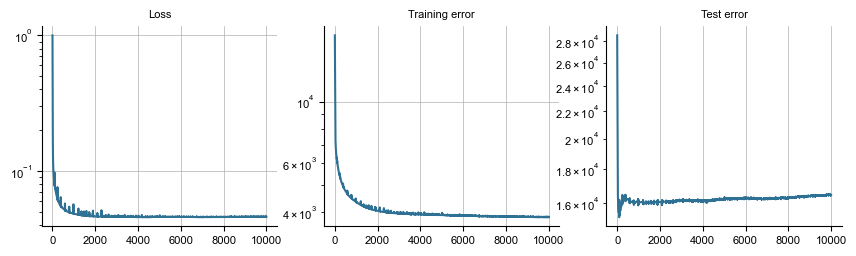

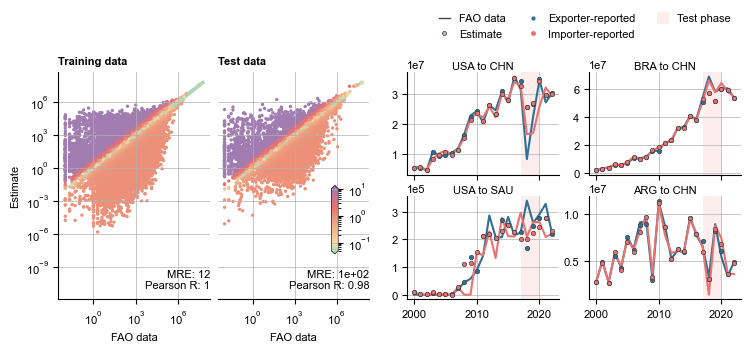

In [157]:
dir = "Results/Test/Soya_new"
plot_loss(dir)
plot_comparison(eval_NN(dir), [('USA', 'CHN'), ('BRA', 'CHN'), ('USA', 'SAU'), ('ARG', 'CHN')]);

## Barley

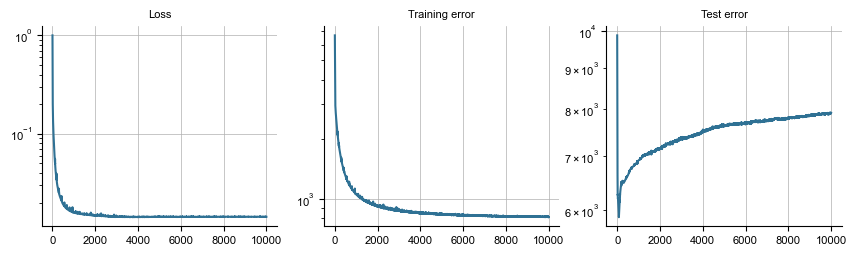

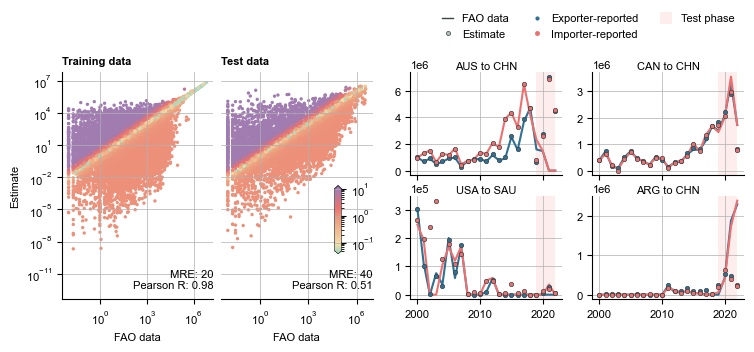

In [159]:
dir = "Results/Test/Barley_new"
plot_loss(dir)
plot_comparison(eval_NN(dir), [('AUS', 'CHN'), ('CAN', 'CHN'), ('USA', 'SAU'), ('ARG', 'CHN')]);

## Wine

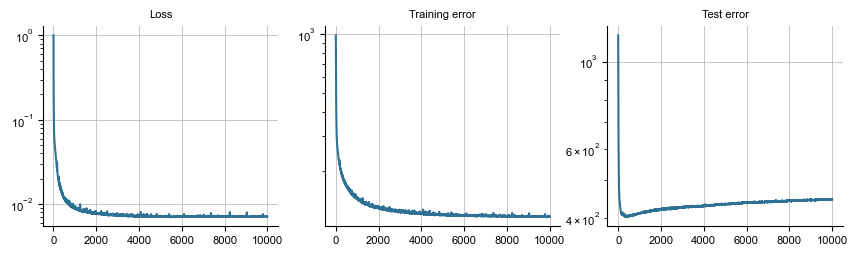

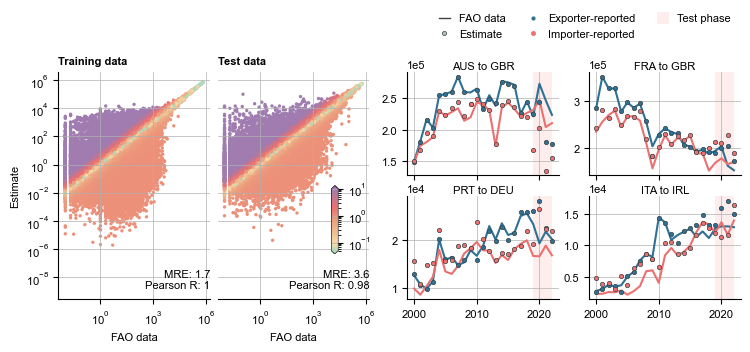

In [160]:
dir = "Results/Test/Wine_new"
plot_loss(dir)
plot_comparison(eval_NN(dir), [('AUS', 'GBR'), ('FRA', 'GBR'), ('PRT', 'DEU'), ('ITA', 'IRL')]);

## Wheat

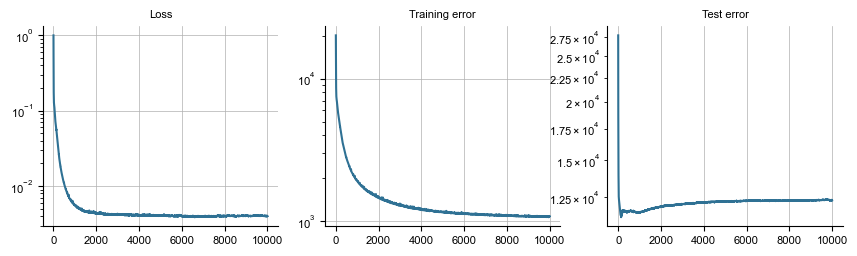

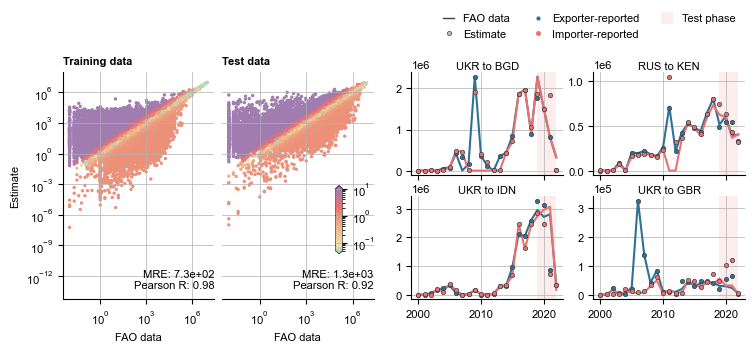

In [161]:
dir = "Results/Test/Wheat_new"
plot_loss(dir);
plot_comparison(eval_NN(dir), [('UKR', 'BGD'), ('RUS', 'KEN'), ('UKR', 'IDN'), ('UKR', 'GBR')]);

## Beef

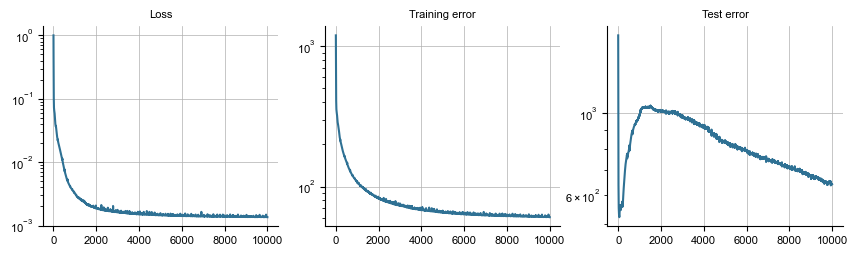

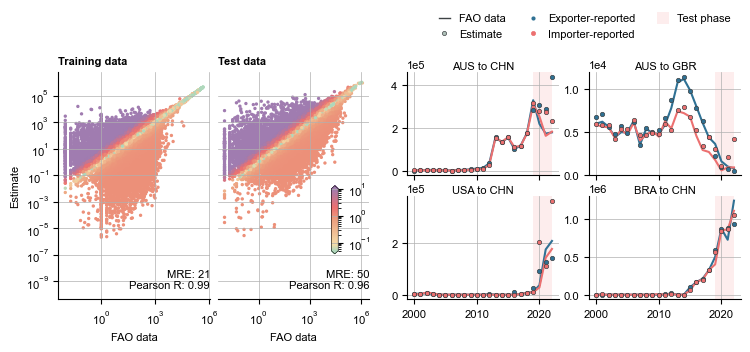

In [162]:
dir = "Results/Test/Beef_new"
plot_loss(dir)
plot_comparison(eval_NN(dir), [('AUS', 'CHN'), ('AUS', 'GBR'), ('USA', 'CHN'), ('BRA', 'CHN')]);